# ML Data Analysis On Diabetes
We are looking at a dataset that was originally from the National Institute of Diabetes and Digestive and Kidney Diseases. All the patients are females and at least 21 years old of Pima Indian heritage. The goal of using ML is to see if we can predict whether or not a patient has diabetes or not and if there are certain variables that are more important in determining it.


We then cleaned the dataset by looking for missing or duplicate entries.
The cleaned dataset is named diabetes.csv


-
---



Dataset: [Diabetes Dataset](https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset/data)


Code Reference: [📊💉 Diabetes Data Dive: Machine Learning Marvel🔍📊](https://www.kaggle.com/code/syedfaizanalii/diabetes-data-dive-machine-learning-marvel)

GitHub Repository: [GitHub Repository](https://github.com/emmacionca/FinalProjectBiomedicalInformatics)

# Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#Import Machine Learning Algorithms
from sklearn.model_selection import train_test_split  # Split data into training and testing sets for model evaluation
from sklearn.linear_model import LogisticRegression  # Logistic Regression for classification tasks
from sklearn.neighbors import KNeighborsClassifier  # KNN for classification

# Import Ensemble Learning Algorithms (combining multiple models for better performance)
from sklearn.ensemble import RandomForestClassifier  # Random Forest for robust classification
from sklearn.ensemble import GradientBoostingClassifier  # Gradient Boosting for decision tree-based learning with improved accuracy

# Evaluation Metrics (assessing model performance)
from sklearn.metrics import confusion_matrix  # Visualize model predictions vs. true labels
from sklearn.metrics import accuracy_score, recall_score, f1_score  # Calculate common performance metrics

# ML

In [5]:
# load csv
df = pd.read_csv
df = pd.read_csv('diabetes.csv')

# separate features and target variable
X = df.drop('Outcome', axis=1)  # Features for model training
y = df['Outcome']              # Target variable for prediction

# split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Function to Evaluates a machine learning model's performance (Classification Report)

def models(model):
    # Print model information
    print("Evaluating Model Name :", model)

    # Train the model on the training data
    model.fit(X_train, y_train)

    # Make predictions on the testing data
    prediction = model.predict(X_test)

    # Evaluate model performance using various metrics

    # Accuracy: Proportion of correct predictions
    accuracy = accuracy_score(prediction, y_test)
    print("Accuracy Score :", accuracy)

    # Recall: Proportion of true positives correctly identified
    recall = recall_score(prediction, y_test)
    print("Recall Score :", recall)

    # F1 Score: Harmonic mean of precision and recall
    f1 = f1_score(prediction, y_test)
    print("F1 Score :", f1)
    sns.heatmap(confusion_matrix(prediction, y_test), annot=True ,fmt = '0.2f',linewidth = .9)

    # add labels to confusion matrix
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.xlabel('True Label')
    plt.ylabel('Predicted Label')
    plt.show()

# Logistic Regression

Evaluating Model Name : LogisticRegression()
Accuracy Score : 0.7467532467532467
Recall Score : 0.6379310344827587
F1 Score : 0.6548672566371682


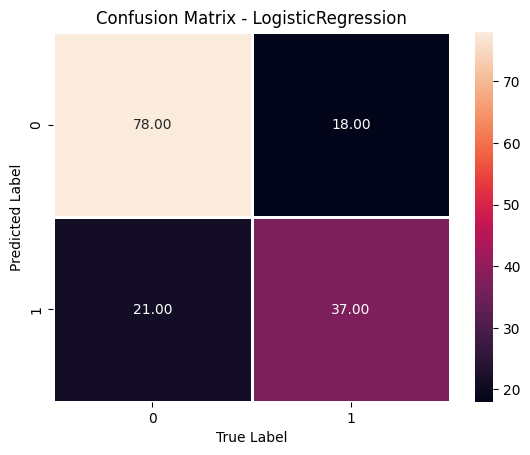

In [21]:
logistic = LogisticRegression()
models(logistic)

# KNeighbors Classifier

Evaluating Model Name : KNeighborsClassifier(n_neighbors=10)
Accuracy Score : 0.7662337662337663
Recall Score : 0.7111111111111111
F1 Score : 0.64


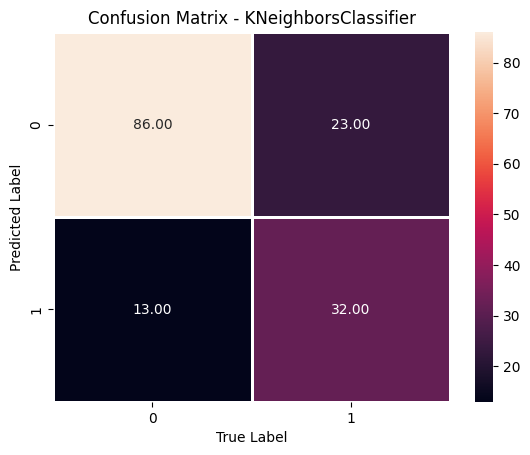

In [22]:
knn = KNeighborsClassifier(n_neighbors=10)
models(knn)

# Random Forrest Classifier

Evaluating Model Name : RandomForestClassifier()
Accuracy Score : 0.7467532467532467
Recall Score : 0.6428571428571429
F1 Score : 0.6486486486486487


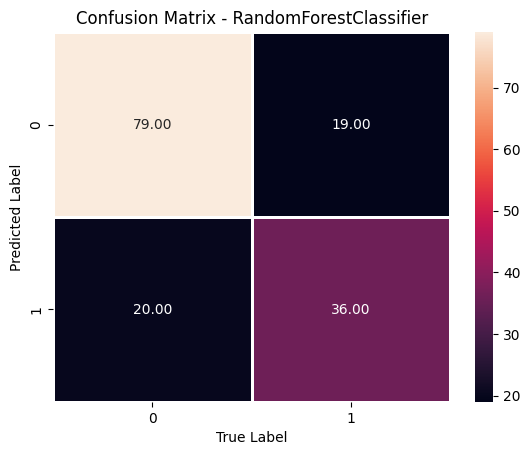

In [23]:
random_forest = RandomForestClassifier()
models(random_forest)

# Cross Validation

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Example for Random Forest
rf = RandomForestClassifier()
scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')  # 5-fold CV
print("Random Forest Cross-Val Accuracy:", scores.mean())

# You can also try other metrics like:
from sklearn.model_selection import cross_validate

results = cross_validate(rf, X, y, cv=5, scoring=['accuracy', 'recall', 'f1'])
print("Average Accuracy:", results['test_accuracy'].mean())
print("Average Recall:", results['test_recall'].mean())
print("Average F1 Score:", results['test_f1'].mean())

Random Forest Cross-Val Accuracy: 0.7630761395467278
Average Accuracy: 0.7722094898565486
Average Recall: 0.5897973445143256
Average F1 Score: 0.6441402659398414


# Insights from these findings will be in the written report and presentation.